# 01 — Data Preparation: Entry Count Prediction

Implements **Steps 1–4** of the `ride-on-entry-prediction` skill.

**Target:** `entrycount` — active competitor entries per class-in-competition.

| Step | Content |
|------|---------|
| 1 | Imports + `.env` |
| 2 | Single embedded-resource query → one row per (class, prize type) |
| 3 | EDA: shape, nulls, distributions |
| 4a | Time features from `classdatetime` |
| 4b | Class dimensions: aggregates (on unique classes) + 5 classname text patterns |
| 4c | Weather via Open-Meteo archive API |
| 4d | Pivot prize rows → one row per class, presence flags, `prize_jackpot_final` (ref) |
| 4e | OHE + drop `drop_cols` + save `data/df_model.csv` |

---
## Step 1 — Imports & Environment

In [3]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv
from supabase import create_client

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

load_dotenv(dotenv_path=Path("../.env"))

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]

print(f"SUPABASE_URL : {SUPABASE_URL[:40]}...")
print("Environment  : OK")

SUPABASE_URL : https://sxplumrexbolpwqacpiz.supabase.co...
Environment  : OK


In [4]:
import sys
!"{sys.executable}" -m pip install arabic-reshaper python-bidi


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 2 — Data Extraction

Single paginated `supabase-py` embedded-resource query.  
The reference SQL this implements (WITH subquery — one row per class per prize type):

```sql
WITH class_entries AS (
    SELECT
        cic.classincompid,
        cic.competitionid,
        cic.classdatetime,
        cic.orderinday,
        COALESCE(cic.organizercost, 0) + COALESCE(cic.federationcost, 0) AS totalcost,
        ct.classname,
        ct.classtypeid,
        f.fieldname,
        c.competitionname,
        r.ranchname,
        r.latitude,
        r.longitude,
        COUNT(CASE WHEN e.entrystatus = 'Active' THEN 1 END) AS entrycount
    FROM classincompetition cic
    JOIN classtype    ct  ON ct.classtypeid   = cic.classtypeid
    JOIN field        f   ON f.fieldid        = ct.fieldid
    JOIN competition  c   ON c.competitionid  = cic.competitionid
    JOIN ranch        r   ON r.ranchid        = c.hostranchid
    LEFT JOIN entry   e   ON e.classincompid  = cic.classincompid
    WHERE c.competitionstatus = 'הסתיימה'
    GROUP BY
        cic.classincompid, cic.competitionid, cic.classdatetime, cic.orderinday,
        cic.organizercost, cic.federationcost,
        ct.classname, ct.classtypeid, f.fieldname,
        c.competitionname, r.ranchname, r.latitude, r.longitude
)
SELECT
    ce.*,
    pt.prizetypename,
    cp.prizeamount
FROM class_entries ce
LEFT JOIN classprize cp ON cp.classincompid = ce.classincompid
LEFT JOIN prizetype  pt ON pt.prizetypeid   = cp.prizetypeid
ORDER BY ce.classdatetime, ce.classincompid, pt.prizetypename;
```

In [5]:
sb = create_client(SUPABASE_URL, SUPABASE_KEY)


def _load_raw() -> list:
    """Single paginated query via PostgREST embedded resources."""
    rows, offset = [], 0
    while True:
        resp = (
            sb.table("classincompetition")
            .select(
                "classincompid, competitionid, classdatetime, orderinday,"
                " organizercost, federationcost,"
                " classtype(classname, classtypeid, field(fieldname)),"
                " competition(competitionname, competitionstatus,"
                "   ranch(ranchname, latitude, longitude)),"
                " entry(entryid, entrystatus),"
                " classprize(prizeamount, prizetype(prizetypename))"
            )
            .range(offset, offset + 999)
            .execute()
        )
        rows.extend(resp.data)
        if len(resp.data) < 1000:
            break
        offset += 1000
    return rows


def _flatten(rows: list) -> pd.DataFrame:
    """
    Flatten nested JSON to one row per (classincompid, prizetypename).
    Mirrors the WITH-subquery SQL:
      - WHERE competitionstatus = 'הסתיימה'
      - COUNT(CASE WHEN entrystatus='Active') AS entrycount
      - LEFT JOIN classprize / prizetype (NULL row for classes with no prizes)
    """
    records = []
    for r in rows:
        comp  = r.get("competition") or {}
        if comp.get("competitionstatus") != "הסתיימה":
            continue
        ct    = r.get("classtype") or {}
        field = ct.get("field") or {}
        ranch = comp.get("ranch") or {}

        entrycount = sum(
            1 for e in (r.get("entry") or [])
            if e.get("entrystatus") == "Active"
        )
        base = {
            "classincompid":  r["classincompid"],
            "competitionid":  r["competitionid"],
            "classdatetime":  r.get("classdatetime"),
            "orderinday":     r.get("orderinday"),
            "totalcost":      float(r.get("organizercost") or 0)
                              + float(r.get("federationcost") or 0),
            "classname":      ct.get("classname"),
            "classtypeid":    ct.get("classtypeid"),
            "fieldname":      field.get("fieldname"),
            "competitionname":comp.get("competitionname"),
            "ranchname":      ranch.get("ranchname"),
            "latitude":       ranch.get("latitude"),
            "longitude":      ranch.get("longitude"),
            "entrycount":     entrycount,
        }

        prizes = r.get("classprize") or []
        if not prizes:
            # Class with no prizes → one NULL-prize row (mirrors LEFT JOIN)
            records.append({**base, "prizetypename": None, "prizeamount": None})
        else:
            for p in prizes:
                pt_name = (p.get("prizetype") or {}).get("prizetypename")
                records.append({
                    **base,
                    "prizetypename": pt_name,
                    "prizeamount":   float(p["prizeamount"])
                                     if p.get("prizeamount") is not None else None,
                })

    df = pd.DataFrame(records)
    df["classdatetime"] = pd.to_datetime(df["classdatetime"], errors="coerce")
    df["orderinday"]    = pd.to_numeric(df["orderinday"],    errors="coerce")
    df["prizeamount"]   = pd.to_numeric(df["prizeamount"],   errors="coerce")
    return df.sort_values(["classdatetime", "classincompid", "prizetypename"]).reset_index(drop=True)


raw = _load_raw()
df  = _flatten(raw)

print(f"Fetched {len(raw):,} raw rows")
print(f"After filter : {df.shape[0]:,} rows, {df['classincompid'].nunique():,} unique classes")
print(f"Columns ({df.shape[1]}): {list(df.columns)}")
df.head(6)

Fetched 1,277 raw rows
After filter : 1,049 rows, 965 unique classes
Columns (15): ['classincompid', 'competitionid', 'classdatetime', 'orderinday', 'totalcost', 'classname', 'classtypeid', 'fieldname', 'competitionname', 'ranchname', 'latitude', 'longitude', 'entrycount', 'prizetypename', 'prizeamount']


,classincompid,competitionid,classdatetime,orderinday,totalcost,classname,classtypeid,fieldname,competitionname,ranchname,latitude,longitude,entrycount,prizetypename,prizeamount
0,619,15,2024-06-06 06:00:00+00:00,1,500.000,Non Pro NRHA,12,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,13,ג'קפוט,140.000
1,619,15,2024-06-06 06:00:00+00:00,1,500.000,Non Pro NRHA,12,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,13,כסף מוסף,4000.000
2,620,15,2024-06-06 06:00:00+00:00,2,360.000,Limited Non Pro NRHA,13,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,15,ג'קפוט,90.000
3,620,15,2024-06-06 06:00:00+00:00,2,360.000,Limited Non Pro NRHA,13,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,15,כסף מוסף,1200.000
4,621,15,2024-06-06 06:00:00+00:00,3,400.000,Limited Open NRHA,8,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,8,ג'קפוט,105.000
5,621,15,2024-06-06 06:00:00+00:00,3,400.000,Limited Open NRHA,8,ריינינג,תחרות בוגרים 3+4 - 2024,דאבל קיי,32.726,35.468,8,כסף מוסף,2000.000


---
## Step 3 — EDA

In [6]:
uniq = df.drop_duplicates(subset=["classincompid"])
print(f"Total rows   : {df.shape[0]:,}  (one per class×prize type)")
print(f"Unique classes: {uniq.shape[0]:,}")
print()
print("Null counts (full DataFrame):")
print(df.isnull().sum().to_string())
print()
print("Data types:")
print(df.dtypes.to_string())

Total rows   : 1,049  (one per class×prize type)
Unique classes: 965

Null counts (full DataFrame):
classincompid        0
competitionid        0
classdatetime        0
orderinday           0
totalcost            0
classname            0
classtypeid          0
fieldname            0
competitionname      0
ranchname            0
latitude            70
longitude           70
entrycount           0
prizetypename      692
prizeamount        692

Data types:
classincompid                    int64
competitionid                    int64
classdatetime      datetime64[us, UTC]
orderinday                       int64
totalcost                      float64
classname                          str
classtypeid                      int64
fieldname                          str
competitionname                    str
ranchname                          str
latitude                       float64
longitude                      float64
entrycount                       int64
prizetypename                      

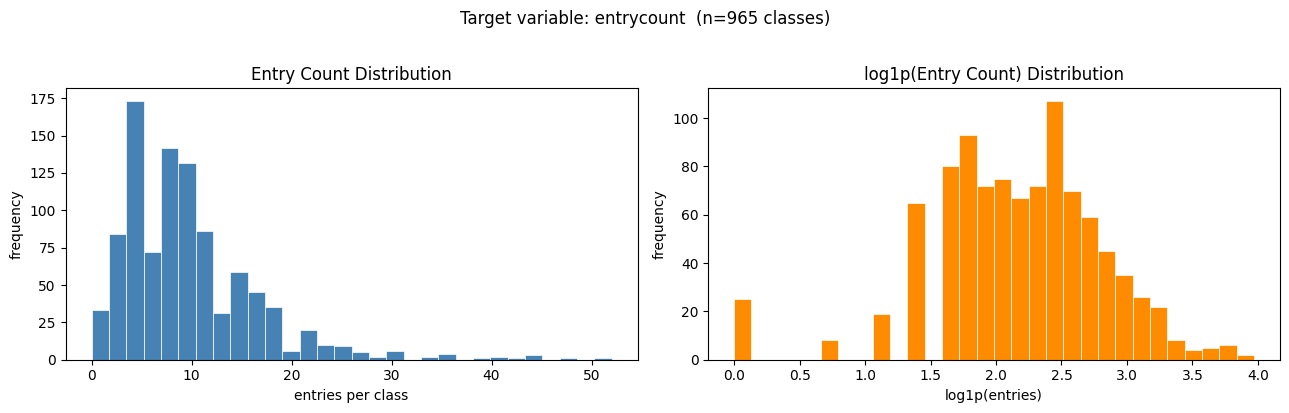

count   965.000
mean      9.720
std       6.960
min       0.000
25%       5.000
50%       8.000
75%      13.000
max      52.000


In [7]:
# entrycount distribution (one point per unique class)
ec = uniq["entrycount"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ec, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Entry Count Distribution")
axes[0].set_xlabel("entries per class")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(ec), bins=30, color="darkorange", edgecolor="white", linewidth=0.5)
axes[1].set_title("log1p(Entry Count) Distribution")
axes[1].set_xlabel("log1p(entries)")
axes[1].set_ylabel("frequency")

plt.suptitle(f"Target variable: entrycount  (n={len(ec):,} classes)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
print(ec.describe().round(2).to_string())

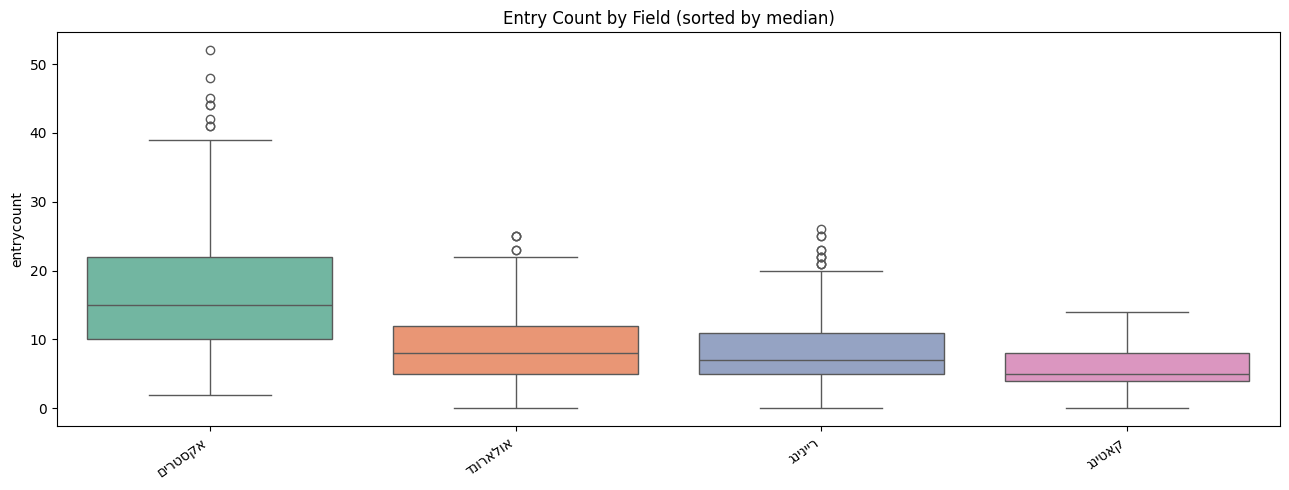

In [8]:
import arabic_reshaper
from bidi.algorithm import get_display

if "fieldname" in uniq.columns and uniq["fieldname"].notna().any():
    order = (
        uniq.groupby("fieldname")["entrycount"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    # Fix Hebrew labels
    fixed_order = [get_display(arabic_reshaper.reshape(str(label))) for label in order]

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=uniq, x="fieldname", y="entrycount", order=order, palette="Set2", ax=ax)
    ax.set_xticklabels(fixed_order, rotation=35, ha="right")
    ax.set_title("Entry Count by Field (sorted by median)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
else:
    print("fieldname column not available.")

---
## Step 4 — Feature Engineering

In [9]:
# 4a — Time features from classdatetime
# Applied to multi-row df (classdatetime is identical for all prize rows of a class)
df_feat = df.copy()

df_feat["class_date"]  = df_feat["classdatetime"].dt.normalize()   # weather merge key
df_feat["month"]       = df_feat["classdatetime"].dt.month
df_feat["day_of_week"] = df_feat["classdatetime"].dt.dayofweek     # Mon=0

print("4a done:", ["month", "day_of_week", "class_date"])
print(df_feat["month"].value_counts().sort_index().to_string())

4a done: ['month', 'day_of_week', 'class_date']
month
3      77
4     198
5      80
6     107
8     114
9     201
10    136
11    107
12     29


In [10]:
# 4b — Class dimensions
# Aggregate features computed on unique classes to avoid prize-row inflation,
# then merged back to all rows.

_uniq = df_feat.drop_duplicates(subset=["classincompid"])

_cpc = (
    _uniq.groupby("competitionid")["classincompid"]
    .count()
    .rename("classes_per_competition")
    .reset_index()
)
_fap = (
    _uniq.groupby("fieldname")["entrycount"]
    .mean()
    .rename("field_avg_past_entries")
    .reset_index()
)
_cap = (
    _uniq.groupby("classname")["entrycount"]
    .mean()
    .rename("classname_avg_past_entries")
    .reset_index()
)

df_feat = (
    df_feat
    .merge(_cpc, on="competitionid", how="left")
    .merge(_fap, on="fieldname",     how="left")
    .merge(_cap, on="classname",     how="left")
)

# Classname structured encoding — 5 dimensions, Hebrew + English patterns
_cn = df_feat["classname"].fillna("").str.lower()

# Dimension 1 — Horse Level (one-hot, mutually exclusive)
df_feat["horse_futurity"] = _cn.str.contains("פטוריטי|futurity", na=False).astype(int)
df_feat["horse_novice"] = (
    _cn.str.contains("נוביס|novice|green horse", na=False)
    & ~_cn.str.contains("פטוריטי|futurity|דרבי|derby", na=False)
).astype(int)
df_feat["horse_derby"] = _cn.str.contains("דרבי|derby", na=False).astype(int)
df_feat["horse_none"] = (
    (df_feat["horse_futurity"] + df_feat["horse_novice"] + df_feat["horse_derby"]) == 0
).astype(int)

# Dimension 2 — Rider Age (one-hot, mutually exclusive)
df_feat["rider_youth"] = _cn.str.contains(
    r"נוער|עד\s*\d+|עד\s*גיל|\b1[0-9]\b|youth|young", na=False, regex=True
).astype(int)
df_feat["rider_adult_plus"] = (
    _cn.str.contains(r"40\+|50\+|בוגרים|prime time", na=False, regex=True)
    & ~df_feat["rider_youth"].astype(bool)
).astype(int)
df_feat["rider_all_ages"] = (
    (df_feat["rider_youth"] + df_feat["rider_adult_plus"]) == 0
).astype(int)

# Dimension 3 — Federation (one-hot, mutually exclusive)
df_feat["fed_NRHA"] = _cn.str.contains("nrha", na=False).astype(int)
df_feat["fed_NCHA"] = _cn.str.contains("ncha", na=False).astype(int)
df_feat["fed_EXCA"] = _cn.str.contains("exca", na=False).astype(int)
df_feat["fed_IEF"] = (
    (df_feat["fed_NRHA"] + df_feat["fed_NCHA"] + df_feat["fed_EXCA"]) == 0
).astype(int)

# Dimension 4 — Rider Level (multi-label, multiple flags can be 1)
df_feat["rider_open"] = _cn.str.contains(r"פתוח|לא מוגבל|unrestricted|\bopen\b", na=False, regex=True).astype(int)
df_feat["rider_non_pro"] = _cn.str.contains("נונ פרו|נונפרו|non pro|nonpro", na=False).astype(int)
df_feat["rider_yaroki"] = _cn.str.contains(r"ירוקי|ירוקי רוכב|רוכב ירוקי|רוכב חדש", na=False).astype(int)
df_feat["rider_pro"] = (
    _cn.str.contains(r"\bpro\b", na=False, regex=True)
    & ~df_feat["rider_non_pro"].astype(bool)
).astype(int)
df_feat["rider_limited"] = (
    _cn.str.contains("מוגבל|limited|limit rider", na=False)
    & ~_cn.str.contains("לא מוגבל|unrestricted", na=False)
).astype(int)

# Dimension 5 — Sub-type within field (multi-label, field-scoped)
# Cutting
df_feat["subtype_cow_horse"] = _cn.str.contains("קאו הורס", na=False).astype(int)
df_feat["subtype_premium"] = _cn.str.contains("פרימיום", na=False).astype(int)
df_feat["subtype_platinum"] = _cn.str.contains("פלאטינום", na=False).astype(int)

# All-Around
df_feat["subtype_trail"] = _cn.str.contains("טרייל", na=False).astype(int)
df_feat["subtype_horsemanship"] = _cn.str.contains("הורסמנשיפ", na=False).astype(int)
df_feat["subtype_pleasure"] = _cn.str.contains("פלז'ר|פלזר", na=False).astype(int)
df_feat["subtype_hunt_seat"] = _cn.str.contains("האנט סיט אקוויטיישן", na=False).astype(int)
df_feat["subtype_hunter_under_saddle"] = _cn.str.contains("האנטר אנדר סאדל", na=False).astype(int)
df_feat["subtype_walk_jog"] = _cn.str.contains("הליכה ג'וג|הליכה גוג", na=False).astype(int)

# Extreme Cowboy
df_feat["subtype_range_sorting"] = _cn.str.contains("ראנג' סורטינג", na=False).astype(int)
df_feat["subtype_intermediate"] = _cn.str.contains("intermediate", na=False).astype(int)
df_feat["subtype_young_gun"] = _cn.str.contains("young gun", na=False).astype(int)

# Practice flag
df_feat["is_practice"] = _cn.str.contains("אימון", na=False).astype(int)

_TEXT_COLS = [
    # Dimension 1 — Horse Level
    "horse_futurity", "horse_novice", "horse_derby", "horse_none",
    # Dimension 2 — Rider Age
    "rider_youth", "rider_adult_plus", "rider_all_ages",
    # Dimension 3 — Federation
    "fed_IEF", "fed_NRHA", "fed_NCHA", "fed_EXCA",
    # Dimension 4 — Rider Level
    "rider_open", "rider_non_pro", "rider_yaroki", "rider_pro", "rider_limited",
    # Dimension 5 — Sub-type within field
    "subtype_cow_horse", "subtype_premium", "subtype_platinum",
    "subtype_trail", "subtype_horsemanship", "subtype_pleasure",
    "subtype_hunt_seat", "subtype_hunter_under_saddle", "subtype_walk_jog",
    "subtype_range_sorting", "subtype_intermediate", "subtype_young_gun",
    # Practice flag
    "is_practice",
]
print("4b done.")
print(f"  aggregate : classes_per_competition, field_avg_past_entries,"
      f" classname_avg_past_entries, totalcost, orderinday")
print(f"  classname dims ({len(_TEXT_COLS)}): {_TEXT_COLS}")
print(f"  dim sums  :\n{df_feat.drop_duplicates('classincompid')[_TEXT_COLS].sum().to_string()}")

4b done.
  aggregate : classes_per_competition, field_avg_past_entries, classname_avg_past_entries, totalcost, orderinday
  classname dims (29): ['horse_futurity', 'horse_novice', 'horse_derby', 'horse_none', 'rider_youth', 'rider_adult_plus', 'rider_all_ages', 'fed_IEF', 'fed_NRHA', 'fed_NCHA', 'fed_EXCA', 'rider_open', 'rider_non_pro', 'rider_yaroki', 'rider_pro', 'rider_limited', 'subtype_cow_horse', 'subtype_premium', 'subtype_platinum', 'subtype_trail', 'subtype_horsemanship', 'subtype_pleasure', 'subtype_hunt_seat', 'subtype_hunter_under_saddle', 'subtype_walk_jog', 'subtype_range_sorting', 'subtype_intermediate', 'subtype_young_gun', 'is_practice']
  dim sums  :
horse_futurity                  21
horse_novice                   120
horse_derby                     17
horse_none                     807
rider_youth                    375
rider_adult_plus                84
rider_all_ages                 506
fed_IEF                        704
fed_NRHA                       191
fed_NCH

In [11]:
# 4c — Weather via Open-Meteo Historical Archive API
# Deduplicate on (class_date, lat, lon) — same location for all prize rows of a class
_WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"


def _fetch_weather(lat: float, lon: float, date_str: str) -> dict:
    if pd.isna(lat) or pd.isna(lon):
        return {"temperature_2m_max": np.nan, "precipitation_sum": np.nan}
    try:
        resp = requests.get(
            _WEATHER_URL,
            params={
                "latitude": lat, "longitude": lon,
                "start_date": date_str, "end_date": date_str,
                "daily": "temperature_2m_max,precipitation_sum",
                "timezone": "auto",
            },
            timeout=15,
        )
        resp.raise_for_status()
        d = resp.json()
        return {
            "temperature_2m_max": d["daily"]["temperature_2m_max"][0],
            "precipitation_sum":  d["daily"]["precipitation_sum"][0],
        }
    except Exception:
        return {"temperature_2m_max": np.nan, "precipitation_sum": np.nan}


weather_keys = (
    df_feat[["class_date", "latitude", "longitude"]]
    .drop_duplicates()
    .dropna(subset=["latitude", "longitude", "class_date"])
)

weather_rows = []
for _, row in weather_keys.iterrows():
    date_str = pd.Timestamp(row["class_date"]).strftime("%Y-%m-%d")
    w = _fetch_weather(row["latitude"], row["longitude"], date_str)
    weather_rows.append({"class_date": row["class_date"],
                          "latitude": row["latitude"],
                          "longitude": row["longitude"], **w})
    time.sleep(0.1)

weather_df = pd.DataFrame(weather_rows)
if not weather_df.empty:
    weather_df["class_date"] = pd.to_datetime(weather_df["class_date"]).dt.normalize()
    df_feat = df_feat.merge(weather_df, on=["class_date", "latitude", "longitude"], how="left")
else:
    df_feat["temperature_2m_max"] = np.nan
    df_feat["precipitation_sum"]  = np.nan

print(
    f"4c done — {len(weather_rows)} unique (date, ranch) combos.  "
    f"Nulls: temperature_2m_max={df_feat['temperature_2m_max'].isna().sum()}, "
    f"precipitation_sum={df_feat['precipitation_sum'].isna().sum()}"
)

4c done — 61 unique (date, ranch) combos.  Nulls: temperature_2m_max=70, precipitation_sum=70


In [12]:
# 4d — Pivot prize rows → one row per class

# Step 1: tag prize type on each row
_pn = df_feat["prizetypename"].fillna("").str.lower()
df_feat["_is_shovar"]      = _pn.str.contains("שובר|shovar|voucher",  regex=True)
df_feat["_is_jackpot"]     = _pn.str.contains("ג.קפוט|jackpot",          regex=True)
df_feat["_is_added_money"] = _pn.str.contains("כסף.מוסף|added.money",   regex=True)

# Step 2: per-class prize flags
prize_flags = (
    df_feat.groupby("classincompid")
    .agg(
        has_prize_shovar      = ("_is_shovar",      "max"),
        has_prize_jackpot     = ("_is_jackpot",     "max"),
        has_prize_added_money = ("_is_added_money", "max"),
        _any_prize            = ("prizetypename",   lambda x: x.notna().any()),
    )
    .reset_index()
)
prize_flags["no_prize"] = (~prize_flags["_any_prize"]).astype(int)
for _c in ["has_prize_shovar", "has_prize_jackpot", "has_prize_added_money"]:
    prize_flags[_c] = prize_flags[_c].astype(int)
prize_flags = prize_flags.drop(columns=["_any_prize"])

# Step 3: jackpot prize amount for prize_jackpot_final
jackpot_amt = (
    df_feat[df_feat["_is_jackpot"]]
    .groupby("classincompid")["prizeamount"]
    .max()
    .reset_index(name="prize_jackpot_posted_amount")
)

# Step 4: collapse to one row per class (drop raw prize + temp cols first)
_prize_raw = ["prizetypename", "prizeamount",
              "_is_shovar", "_is_jackpot", "_is_added_money"]
df_wide = (
    df_feat.drop(columns=_prize_raw)
    .drop_duplicates(subset=["classincompid"])
    .merge(prize_flags, on="classincompid", how="left")
    .merge(jackpot_amt, on="classincompid", how="left")
    .reset_index(drop=True)
)

# Step 5: prize_jackpot_final (reference only — dropped in 4e)
df_wide["prize_jackpot_final"] = (
    df_wide["prize_jackpot_posted_amount"].fillna(0) * df_wide["entrycount"]
)
df_feat = df_wide

print(f"4d done — pivoted to {df_feat.shape[0]:,} rows (one per class)")
print(f"Prize flags:\n{df_feat[['has_prize_shovar','has_prize_jackpot','has_prize_added_money','no_prize']].sum().to_string()}")
print(f"prize_jackpot_final range: {df_feat['prize_jackpot_final'].min():.0f}–{df_feat['prize_jackpot_final'].max():.0f}")

4d done — pivoted to 965 rows (one per class)
Prize flags:
has_prize_shovar          15
has_prize_jackpot        248
has_prize_added_money     94
no_prize                 692
prize_jackpot_final range: 0–19800


In [13]:
# 4e — One-hot encode month + fieldname
_month_dummies = pd.get_dummies(df_feat["month"], prefix="month", drop_first=True, dtype=int)
df_feat = pd.concat([df_feat, _month_dummies], axis=1)

df_feat = pd.get_dummies(
    df_feat,
    columns=["fieldname"],
    prefix=["field"],
    drop_first=False,
    dtype=int,
)
_ohe = [c for c in df_feat.columns if c.startswith(("month_", "field_"))]
print(f"OHE added {len(_ohe)} columns: {_ohe}")

# Drop all identifier + working columns
drop_cols = [
    "classincompid", "competitionid", "classtypeid",
    "classname", "competitionname", "ranchname",
    "classdatetime", "class_date",
    "latitude", "longitude",
    "month",                           # raw integer, replaced by month_* dummies
    "prizetypename", "prizeamount",   # raw prize cols (absent after 4d; listed for safety)
    "prize_jackpot_final",            # reference only
]
_drop_existing = [c for c in drop_cols if c in df_feat.columns]
df_model = df_feat.drop(columns=_drop_existing)

print(f"Dropped {len(_drop_existing)} columns.")
print(f"df_model: {df_model.shape[0]:,} rows × {df_model.shape[1]} cols")

OHE added 13 columns: ['field_avg_past_entries', 'month_4', 'month_5', 'month_6', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'field_אולארונד', 'field_אקסטרים', 'field_קאטינג', 'field_ריינינג']
Dropped 12 columns.
df_model: 965 rows × 55 cols


---
## Save & Summary

In [14]:
Path("../data").mkdir(parents=True, exist_ok=True)
df_model.to_csv("../data/df_model.csv", index=False)

print("Saved : ../data/df_model.csv")
print(f"Shape : {df_model.shape}")
print(f"\nColumns ({len(df_model.columns)}):")
for col in df_model.columns:
    nulls = df_model[col].isna().sum()
    print(f"  {col:<42} {str(df_model[col].dtype):<10} nulls={nulls}")

Saved : ../data/df_model.csv
Shape : (965, 55)

Columns (55):
  orderinday                                 int64      nulls=0
  totalcost                                  float64    nulls=0
  entrycount                                 int64      nulls=0
  day_of_week                                int32      nulls=0
  classes_per_competition                    int64      nulls=0
  field_avg_past_entries                     float64    nulls=0
  classname_avg_past_entries                 float64    nulls=0
  horse_futurity                             int64      nulls=0
  horse_novice                               int64      nulls=0
  horse_derby                                int64      nulls=0
  horse_none                                 int64      nulls=0
  rider_youth                                int64      nulls=0
  rider_adult_plus                           int64      nulls=0
  rider_all_ages                             int64      nulls=0
  fed_NRHA                                